<a href="https://colab.research.google.com/github/ImageForgeryLocalization-Compression/compression-aware-image-forgery-localization/blob/main/myimplementation_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/multimediaFor/MPC.git
%cd MPC

Cloning into 'MPC'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 99 (delta 27), reused 68 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 510.58 KiB | 8.51 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/MPC


In [3]:
!pip install -q albumentations==1.3.1 fvcore opencv-python opencv-python-headless torchsummary gdown scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.2 MB/s eta 0:00:00


In [11]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
zip_path = '/content/drive/MyDrive/casiaV2.zip'  # adjust to your actual Drive path
extract_path = '/content/CASIA2_extracted'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete:", os.path.isdir(os.path.join(extract_path, 'CASIA2')))

Mounted at /content/drive
Extraction complete: True


In [12]:
import os
print("Tp exists:", os.path.isdir('/content/CASIA2_extracted/CASIA2/Tp'))
print("Au exists:", os.path.isdir('/content/CASIA2_extracted/CASIA2/Au'))
print("GT exists:", os.path.isdir('/content/CASIA2_extracted/CASIA2/CASIA 2 Groundtruth'))

Tp exists: True
Au exists: True
GT exists: True


In [13]:
CASIA2_ROOT = '/content/CASIA2_extracted/CASIA2'
TP_DIR = os.path.join(CASIA2_ROOT, 'Tp')
AU_DIR = os.path.join(CASIA2_ROOT, 'Au')
GT_DIR = os.path.join(CASIA2_ROOT, 'CASIA 2 Groundtruth')

In [14]:
import glob
import numpy as np

# --- diagnostic: check what's actually in GT_DIR ---
print("Sample files in GT_DIR:", os.listdir(GT_DIR)[:10])
print("Sample files in TP_DIR:", os.listdir(TP_DIR)[:10])

os.makedirs('flist', exist_ok=True)

pairs = []
unmatched = 0
for mask_path in sorted(glob.glob(os.path.join(GT_DIR, '*_gt.png'))):
    stem = os.path.basename(mask_path)[:-len('_gt.png')]
    candidates = glob.glob(os.path.join(TP_DIR, stem + '.*'))
    if candidates:
        pairs.append((candidates[0], mask_path))
    else:
        unmatched += 1

print(f'Matched pairs: {len(pairs)}   Unmatched masks: {unmatched}')
assert len(pairs) > 0, 'No pairs matched — double-check CASIA2_ROOT / TP_DIR.'

# hold out a random test split (e.g. 500 images) so numbers reflect held-out performance
import random
random.seed(0)
random.shuffle(pairs)
TEST_N = min(500, len(pairs))
test_pairs = pairs[:TEST_N]

flist_path = 'flist/CASIA2_test_%d.npy' % len(test_pairs)
np.save(flist_path, np.array(test_pairs))
print('Saved flist ->', flist_path, '(', len(test_pairs), 'pairs )')

Sample files in GT_DIR: ['Tp_D_NRN_M_O_sec10105_cha10104_10027_gt.png', 'Tp_D_NRN_M_B_sec00085_cha00072_11458_gt.png', 'Tp_S_NRN_S_N_art00063_art00063_01028_gt.png', 'Tp_D_NRN_M_N_nat10138_nat00095_11940_gt.png', 'Tp_D_NRN_S_B_ani00028_ani00029_20111_gt.png', 'Tp_D_NRN_M_N_nat00025_nat00028_11037_gt.png', 'Tp_D_NNN_S_B_cha00100_cha00020_00420_gt.png', 'Tp_D_NNN_S_B_ani00076_ani00077_00196_gt.png', 'Tp_S_NNN_S_M_ind00055_ind00055_10906_gt.png', 'Tp_D_NRN_M_N_nat10160_nat10147_12069_gt.png']
Sample files in TP_DIR: ['Tp_D_NRN_S_N_art10106_cha00067_11593.jpg', 'Tp_D_NRN_M_B_nat00098_arc00065_11449.jpg', 'Tp_D_NRN_M_B_arc00076_arc00069_11190.jpg', 'Tp_S_NRN_S_O_ani10103_ani10103_10634.jpg', 'Tp_D_NRN_S_B_art00063_ani00058_00528.tif', 'Tp_S_NNN_S_N_nat10157_nat10157_12038.jpg', 'Tp_S_CRN_S_B_ind00037_ind00037_10872.jpg', 'Tp_S_CNN_M_N_art00063_art00063_10524.tif', 'Tp_S_NNN_S_B_art00047_art00047_01407.tif', 'Tp_D_NRN_M_N_cha10141_cha10142_12236.jpg']
Matched pairs: 4981   Unmatched masks: 1

In [15]:
!ls /content

CASIA2_extracted  drive  MPC  sample_data


In [16]:
import glob
import numpy as np

os.makedirs('flist', exist_ok=True)

pairs = []
unmatched = 0
for mask_path in sorted(glob.glob(os.path.join(GT_DIR, '*_gt.png'))):
    stem = os.path.basename(mask_path)[:-len('_gt.png')]
    candidates = glob.glob(os.path.join(TP_DIR, stem + '.*'))
    if candidates:
        pairs.append((candidates[0], mask_path))
    else:
        unmatched += 1

print(f'Matched pairs: {len(pairs)}   Unmatched masks: {unmatched}')
assert len(pairs) > 0, 'No pairs matched — double-check CASIA2_ROOT / TP_DIR.'

# hold out a random test split (e.g. 500 images) so numbers reflect held-out performance
import random
random.seed(0)
random.shuffle(pairs)
TEST_N = min(500, len(pairs))
test_pairs = pairs[:TEST_N]

flist_path = 'flist/CASIA2_test_%d.npy' % len(test_pairs)
np.save(flist_path, np.array(test_pairs))
print('Saved flist ->', flist_path, '(', len(test_pairs), 'pairs )')

Matched pairs: 4981   Unmatched masks: 141
Saved flist -> flist/CASIA2_test_500.npy ( 500 pairs )


In [17]:
%cd /content/MPC/CATNet_dataset_train/stage2
import os
os.makedirs('weights', exist_ok=True)

# MPC_CATNet_stage2_weights.pth (generalization checkpoint)
!gdown --id 1vXDvrTVizINKcR_MgdA_uuTWcB3I4HdI -O weights/MPC_CATNet_stage2_weights.pth

# MPC_CASIAv2_stage2_weights.pth (trained on CASIA2 itself — reference only)
!gdown --id 148gv5ovxrQR0QZL2rB3Jt-9lwAS_AH0d -O weights/MPC_CASIAv2_stage2_weights.pth

!ls -lh weights/

/content/MPC/CATNet_dataset_train/stage2
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1vXDvrTVizINKcR_MgdA_uuTWcB3I4HdI
From (redirected): https://drive.google.com/uc?id=1vXDvrTVizINKcR_MgdA_uuTWcB3I4HdI&confirm=t&uuid=223bf9ca-8ad1-4ae5-bc75-ce561977c97e
To: /content/MPC/CATNet_dataset_train/stage2/weights/MPC_CATNet_stage2_weights.pth
100% 183M/183M [00:01<00:00, 117MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=148gv5ovxrQR0QZL2rB3Jt-9lwAS_AH0d
From (redirected): https://drive.google.com/uc?id=148gv5ovxrQR0QZL

In [18]:
import torch
import torch.nn as nn
import logging as logger
from model import MyModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

class MPC(nn.Module):
    def __init__(self, weight_path):
        super(MPC, self).__init__()
        self.cur_net = MyModel().to(device)
        self._load(self.cur_net, weight_path)
        self.cur_net.eval()

    def process(self, Ii):
        with torch.no_grad():
            Fo = self.cur_net(Ii)
        return torch.sigmoid(Fo)

    def _load(self, model, path):
        weights = torch.load(path, map_location=device)
        model_state_dict = model.state_dict()
        loaded, missing, mismatched = [], [], []
        for name, param in weights.items():
            if name in model_state_dict:
                if param.shape == model_state_dict[name].shape:
                    model_state_dict[name].copy_(param)
                    loaded.append(name)
                else:
                    mismatched.append(name)
            else:
                missing.append(name)
        model.load_state_dict(model_state_dict)
        print(f'[{os.path.basename(path)}] loaded {len(loaded)} layers, '
              f'{len(missing)} missing, {len(mismatched)} shape-mismatched.')

model_generalization = MPC('weights/MPC_CATNet_stage2_weights.pth')
model_casia_trained   = MPC('weights/MPC_CASIAv2_stage2_weights.pth')

Using device: cuda
[MPC_CATNet_stage2_weights.pth] loaded 2264 layers, 0 missing, 0 shape-mismatched.
[MPC_CASIAv2_stage2_weights.pth] loaded 2262 layers, 7 missing, 2 shape-mismatched.


In [19]:
import cv2
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

INPUT_SIZE = 512

def thresholding(x, thres=0.5):
    x = x.copy()
    x[x <= int(thres * 255)] = 0
    x[x > int(thres * 255)] = 255
    return x

def metric_iou(pred, gt):
    if pred.shape != gt.shape:
        pred = cv2.resize(pred.astype(np.uint8), (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)
    intersection = np.logical_and(pred, gt)
    union = np.logical_or(pred, gt)
    if union.sum() == 0:
        return 1.0
    return intersection.sum() / (union.sum() + 1e-6)

def load_pair(img_path, mask_path):
    img = cv2.imread(img_path)[..., ::-1]
    H, W = img.shape[:2]
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)   # <-- ADD THIS LINE
    mask = thresholding(mask)
    img_r = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE)).astype('float32') / 255.
    tensor = torch.from_numpy(img_r).permute(2, 0, 1).unsqueeze(0).float().to(device)
    return tensor, mask, (H, W), img

@torch.no_grad()
def evaluate(model, pairs, max_images=None, tag=''):
    n = len(pairs) if max_images is None else min(max_images, len(pairs))
    f1s, ious, accs = [], [], []
    for img_path, mask_path in pairs[:n]:
        tensor, gt_mask, (H, W), _ = load_pair(img_path, mask_path)
        pred = model.process(tensor)                       # [1,1,h,w] in (0,1)
        pred = pred.squeeze().cpu().numpy() * 255.
        pred_resized = cv2.resize(pred, (W, H))
        pred_bin = thresholding(pred_resized)

        gt_flat = (gt_mask.flatten() / 255.).astype(np.uint8)
        pred_flat = (pred_bin.flatten() / 255.).astype(np.uint8)

        f1s.append(f1_score(gt_flat, pred_flat, zero_division=1))
        accs.append(accuracy_score(gt_flat, pred_flat))
        ious.append(metric_iou(pred_bin / 255., gt_mask / 255.))

    print(f'--- {tag} (n={n}) ---')
    print(f'  Mean F1 Score      : {np.mean(f1s):.4f}')
    print(f'  Mean IoU           : {np.mean(ious):.4f}')
    print(f'  Mean Pixel Accuracy: {np.mean(accs):.4f}')
    return np.mean(f1s), np.mean(ious), np.mean(accs)

print('Evaluating on', len(test_pairs), 'held-out CASIA2 tampered images...\n')
gen_f1, gen_iou, gen_acc = evaluate(model_generalization, test_pairs, tag='MPC_CATNet_stage2_weights (generalization)')


Evaluating on 500 held-out CASIA2 tampered images...

--- MPC_CATNet_stage2_weights (generalization) (n=500) ---
  Mean F1 Score      : 0.7360
  Mean IoU           : 0.6756
  Mean Pixel Accuracy: 0.9638


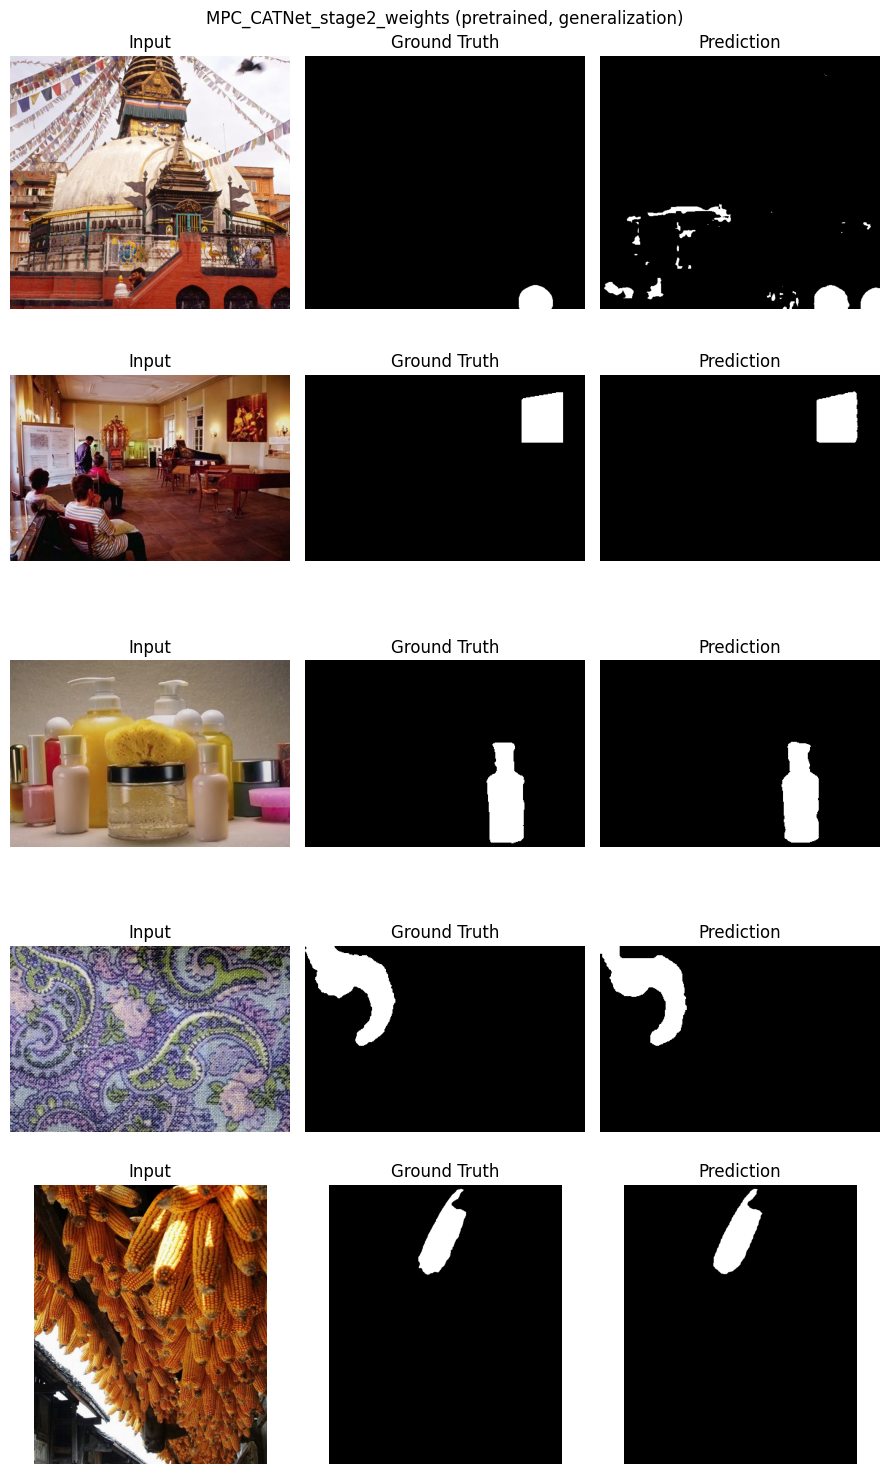

In [20]:
import matplotlib.pyplot as plt

def show_examples(model, pairs, k=5, tag=''):
    fig, axes = plt.subplots(k, 3, figsize=(9, 3 * k))
    for i in range(k):
        img_path, mask_path = pairs[i]
        tensor, gt_mask, (H, W), orig_img = load_pair(img_path, mask_path)
        with torch.no_grad():
            pred = model.process(tensor).squeeze().cpu().numpy() * 255.
        pred_resized = thresholding(cv2.resize(pred, (W, H)))

        axes[i, 0].imshow(orig_img); axes[i, 0].set_title('Input'); axes[i, 0].axis('off')
        axes[i, 1].imshow(gt_mask, cmap='gray'); axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')
        axes[i, 2].imshow(pred_resized, cmap='gray'); axes[i, 2].set_title('Prediction'); axes[i, 2].axis('off')
    fig.suptitle(tag)
    plt.tight_layout()
    plt.savefig('demo_output_pretrained.png', dpi=150, bbox_inches='tight')
    plt.show()

show_examples(model_generalization, test_pairs, k=5, tag='MPC_CATNet_stage2_weights (pretrained, generalization)')

In [21]:
from PIL import Image
import io
import numpy as np

def simulate_compression_generation(img_bgr, quality=50, generations=1):
    """Takes an OpenCV BGR image array, simulates N rounds of JPEG re-compression."""
    img_rgb = img_bgr[..., ::-1]
    pil_img = Image.fromarray(img_rgb.astype('uint8')).convert('RGB')

    for _ in range(generations):
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        pil_img = Image.open(buffer).convert('RGB')

    result = np.array(pil_img)[..., ::-1]  # back to BGR
    return result

In [22]:
import matplotlib.pyplot as plt

def visualize_compression_generations(img_path, mask_path, model, generations_list=[0,1,2,3], quality=50):
    img_bgr = cv2.imread(img_path)

    fig, axes = plt.subplots(2, len(generations_list), figsize=(4*len(generations_list), 8))

    for i, gen in enumerate(generations_list):
        # reuse your existing function unchanged
        compressed_img = simulate_compression_generation(img_bgr, quality=quality, generations=gen)

        # run through model to get predicted mask — adapt this line to match
        # however you currently call the model in evaluate()
        pred_mask = thresholding(model(compressed_img))

        axes[0, i].imshow(cv2.cvtColor(compressed_img, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f"Gen {gen} - Input")
        axes[0, i].axis('off')

        axes[1, i].imshow(pred_mask, cmap='gray')
        axes[1, i].set_title(f"Gen {gen} - Predicted Mask")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [23]:
def load_pair_compressed(img_path, mask_path, generations=0, quality=50):
    img = cv2.imread(img_path)
    H, W = img.shape[:2]

    if generations > 0:
        img = simulate_compression_generation(img, quality=quality, generations=generations)

    img = img[..., ::-1]  # BGR -> RGB
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
    mask = thresholding(mask)

    img_r = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE)).astype('float32') / 255.
    tensor = torch.from_numpy(img_r).permute(2, 0, 1).unsqueeze(0).float().to(device)
    return tensor, mask, (H, W), img

In [24]:
@torch.no_grad()
def evaluate_at_generation(model, pairs, generations, quality=50, max_images=100, tag=''):
    n = min(max_images, len(pairs))
    f1s, ious, accs = [], [], []

    for img_path, mask_path in pairs[:n]:
        tensor, gt_mask, (H, W), _ = load_pair_compressed(img_path, mask_path, generations=generations, quality=quality)
        pred = model.process(tensor)
        pred = pred.squeeze().cpu().numpy() * 255.
        pred_resized = cv2.resize(pred, (W, H))
        pred_bin = thresholding(pred_resized)

        gt_flat = (gt_mask.flatten() / 255.).astype(np.uint8)
        pred_flat = (pred_bin.flatten() / 255.).astype(np.uint8)

        f1s.append(f1_score(gt_flat, pred_flat, zero_division=1))
        accs.append(accuracy_score(gt_flat, pred_flat))
        ious.append(metric_iou(pred_bin / 255., gt_mask / 255.))

    print(f'--- Generation {generations} (n={n}) ---')
    print(f'  Mean F1 Score      : {np.mean(f1s):.4f}')
    print(f'  Mean IoU           : {np.mean(ious):.4f}')
    print(f'  Mean Pixel Accuracy: {np.mean(accs):.4f}')
    return np.mean(f1s), np.mean(ious), np.mean(accs)

In [25]:
generations_to_test = [0, 1, 2, 3]
results = {}

for gen in generations_to_test:
    f1, iou, acc = evaluate_at_generation(model_generalization, test_pairs, generations=gen, quality=50, max_images=100)
    results[gen] = {'f1': f1, 'iou': iou, 'acc': acc}

--- Generation 0 (n=100) ---
  Mean F1 Score      : 0.7379
  Mean IoU           : 0.6712
  Mean Pixel Accuracy: 0.9674
--- Generation 1 (n=100) ---
  Mean F1 Score      : 0.3953
  Mean IoU           : 0.3143
  Mean Pixel Accuracy: 0.9110
--- Generation 2 (n=100) ---
  Mean F1 Score      : 0.3940
  Mean IoU           : 0.3135
  Mean Pixel Accuracy: 0.9103
--- Generation 3 (n=100) ---
  Mean F1 Score      : 0.3920
  Mean IoU           : 0.3122
  Mean Pixel Accuracy: 0.9098


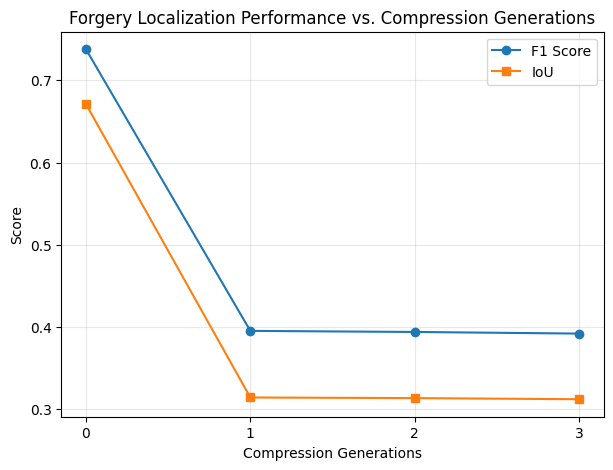

In [26]:
import matplotlib.pyplot as plt

gens = list(results.keys())
f1_values = [results[g]['f1'] for g in gens]
iou_values = [results[g]['iou'] for g in gens]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gens, f1_values, marker='o', label='F1 Score')
ax.plot(gens, iou_values, marker='s', label='IoU')
ax.set_xlabel('Compression Generations')
ax.set_ylabel('Score')
ax.set_title('Forgery Localization Performance vs. Compression Generations')
ax.set_xticks(gens)
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('/content/compression_robustness_curve.png', dpi=150, bbox_inches='tight')
plt.show()

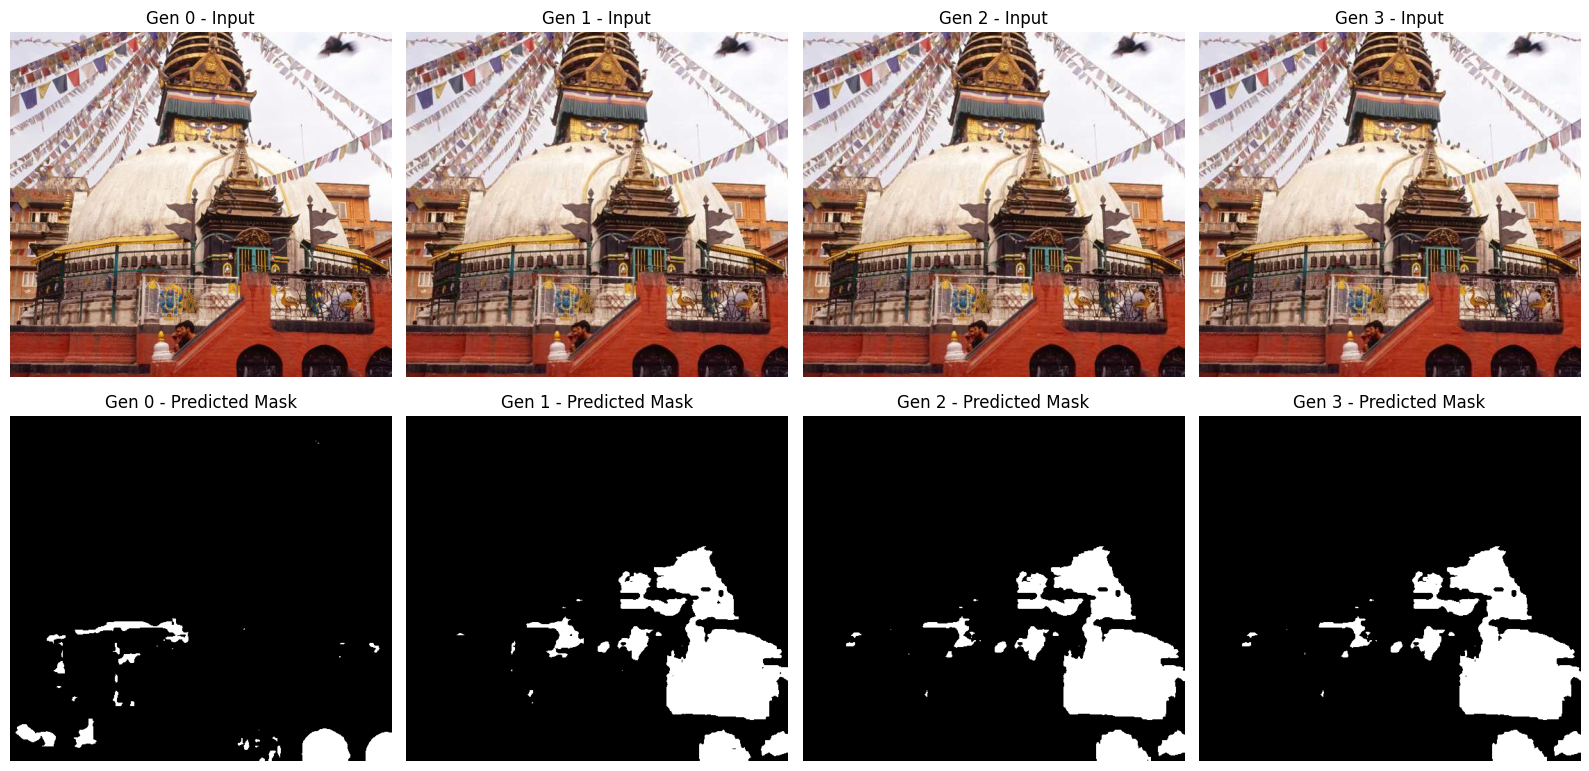

In [27]:
def show_compression_examples(model, pairs, generations_list, example_idx=0, quality=50):
    img_path, mask_path = pairs[example_idx]
    n = len(generations_list)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

    for i, gen in enumerate(generations_list):
        tensor, gt_mask, (H, W), orig_img = load_pair_compressed(img_path, mask_path, generations=gen, quality=quality)
        pred = model.process(tensor)
        pred_np = pred.squeeze().cpu().numpy() * 255.
        pred_resized = cv2.resize(pred_np, (W, H))
        pred_bin = thresholding(pred_resized)

        axes[0, i].imshow(orig_img)  # already RGB from load_pair_compressed
        axes[0, i].set_title(f"Gen {gen} - Input")
        axes[0, i].axis('off')

        axes[1, i].imshow(pred_bin, cmap='gray')
        axes[1, i].set_title(f"Gen {gen} - Predicted Mask")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('/content/compression_generation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_compression_examples(model_generalization, test_pairs, generations_list=[0, 1, 2, 3])

In [28]:
def load_pair_variable_compression(img_path, mask_path, quality_sequence):
    """quality_sequence e.g. [85, 65, 45] simulates 3 different platforms."""
    img = cv2.imread(img_path)
    H, W = img.shape[:2]

    for q in quality_sequence:
        img = simulate_compression_generation(img, quality=q, generations=1)

    img = img[..., ::-1]
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
    mask = thresholding(mask)

    img_r = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE)).astype('float32') / 255.
    tensor = torch.from_numpy(img_r).permute(2, 0, 1).unsqueeze(0).float().to(device)
    return tensor, mask, (H, W), img

In [29]:
@torch.no_grad()
def evaluate_variable_compression(model, pairs, quality_sequence, max_images=100, tag=''):
    n = min(max_images, len(pairs))
    f1s, ious, accs = [], [], []

    for img_path, mask_path in pairs[:n]:
        tensor, gt_mask, (H, W), _ = load_pair_variable_compression(img_path, mask_path, quality_sequence)
        pred = model.process(tensor)
        pred = pred.squeeze().cpu().numpy() * 255.
        pred_resized = cv2.resize(pred, (W, H))
        pred_bin = thresholding(pred_resized)

        gt_flat = (gt_mask.flatten() / 255.).astype(np.uint8)
        pred_flat = (pred_bin.flatten() / 255.).astype(np.uint8)

        f1s.append(f1_score(gt_flat, pred_flat, zero_division=1))
        accs.append(accuracy_score(gt_flat, pred_flat))
        ious.append(metric_iou(pred_bin / 255., gt_mask / 255.))

    print(f'--- {tag} (n={n}) ---')
    print(f'  Mean F1 Score      : {np.mean(f1s):.4f}')
    print(f'  Mean IoU           : {np.mean(ious):.4f}')
    print(f'  Mean Pixel Accuracy: {np.mean(accs):.4f}')
    return np.mean(f1s), np.mean(ious), np.mean(accs)

In [30]:
quality_scenarios = {
    0: [],                    # original, no compression
    1: [85],                  # e.g. Instagram
    2: [85, 65],              # + WhatsApp forward
    3: [85, 65, 45],          # + Twitter re-upload
}

variable_results = {}

for gen, quality_seq in quality_scenarios.items():
    f1, iou, acc = evaluate_variable_compression(
        model_generalization, test_pairs, quality_seq, max_images=100, tag=f'Generation {gen}'
    )
    variable_results[gen] = {'f1': f1, 'iou': iou, 'acc': acc}

--- Generation 0 (n=100) ---
  Mean F1 Score      : 0.7379
  Mean IoU           : 0.6712
  Mean Pixel Accuracy: 0.9674
--- Generation 1 (n=100) ---
  Mean F1 Score      : 0.5388
  Mean IoU           : 0.4670
  Mean Pixel Accuracy: 0.9389
--- Generation 2 (n=100) ---
  Mean F1 Score      : 0.3466
  Mean IoU           : 0.2694
  Mean Pixel Accuracy: 0.9192
--- Generation 3 (n=100) ---
  Mean F1 Score      : 0.3300
  Mean IoU           : 0.2618
  Mean Pixel Accuracy: 0.9142


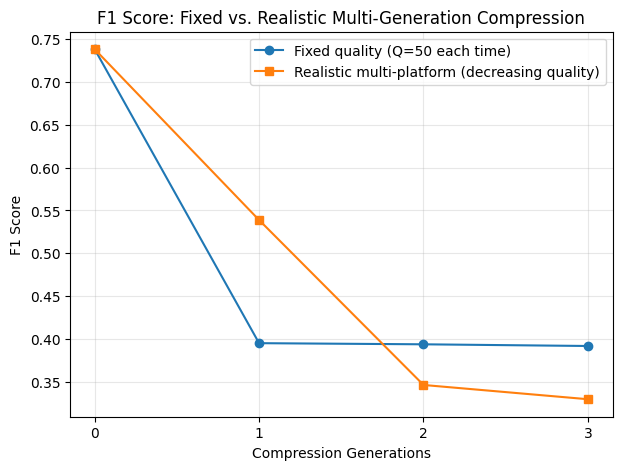

In [31]:
import matplotlib.pyplot as plt

gens = list(variable_results.keys())
f1_fixed = [results[g]['f1'] for g in gens]           # your earlier fixed-quality=50 results
f1_variable = [variable_results[g]['f1'] for g in gens]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gens, f1_fixed, marker='o', label='Fixed quality (Q=50 each time)')
ax.plot(gens, f1_variable, marker='s', label='Realistic multi-platform (decreasing quality)')
ax.set_xlabel('Compression Generations')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score: Fixed vs. Realistic Multi-Generation Compression')
ax.set_xticks(gens)
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('/content/compression_comparison_curve.png', dpi=150, bbox_inches='tight')
plt.show()